# Simulation

In [1]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

import os
import argparse
import numpy as np
import pybullet as p
import pybullet_data
import socket
import json
import pandas as pd
import torch
import torch.optim as optim
import torch.nn.functional as F
import collections
from datetime import datetime
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
# Increase the embed limit to 50 Megabytes
mpl.rcParams['animation.embed_limit'] = 70.0

# from geometric_control import GeometricControl
from mellinger_control import MellingerControl
from geometric_control import GeometricControl

from payload_env import PayloadEnv
from utils import get_trajectory, get_kinetic_energy, show_evaluation, calculate_total_cog, calculate_payload_offset, get_3d_frame_coordinates, animate_episode_flight, calculate_true_principal_inertia, get_composite_inertia
# from pinn_cog_detection import PINNCoGDetection, calculate_total_pinn_loss
from pinn_inverse_estimator import Inverse6DoFPINN, train_pinn_step

## Constants

In [2]:
# --- Constants ---
RATE_HZ = 240.0
TIME_STEP = 1.0 / RATE_HZ
GRAVITY_MSS = 9.81
SIMULATION_DURATION = 90 # simulation time in seconds
MAX_DIST_ERR = 5
TOTAL_EPISODES = 1
MAX_DRONE_THRUST = 50
TOTAL_SYSTEM_MASS = 7.8
WINDOW_SIZE = 50          
OPTIMIZE_EVERY_N_STEPS = 5 
STEPS_PER_OPTIMIZATION = 3
FRAME_MASS = 6.8 
ENABLE_PINN = True
LAMBDA_DATA = 1
LAMBDA_TRANS = 0
LAMBDA_ROT = 0
OFFSET_X = 0.1
OFFSET_Y = 0.1
PATH_TRAJECTORY = "lawn"

## Arguments

In [3]:
USE_PINN = False
WEIGHTS_FILE_PATH = "pinn_estimator_weights.pth"
URDF_FILE_PATH = "final_assembly.urdf"
VIRTUAL_LEADER_FILE_PATH = "virtual_leader.urdf"
DEBUG = False
MODEL_DIR = "nn_models"


## Define the Leader

In [4]:
leader = MellingerControl(use_pinn=USE_PINN, weights_file_path=WEIGHTS_FILE_PATH, mass_total= TOTAL_SYSTEM_MASS)
# leader = GeometricControl(use_pinn=USE_PINN, weights_file_path=WEIGHTS_FILE_PATH, mass_total= TOTAL_SYSTEM_MASS)


# Define the Environment

In [5]:
# --- PyBullet initialization ---
# if args.vis:
#     p.connect(p.GUI) # showing visualization
# else:
# p.connect(p.DIRECT)
p.connect(p.GUI)
log_id = p.startStateLogging(p.STATE_LOGGING_VIDEO_MP4, "simulation_recording.mp4")

p.setTimeStep(TIME_STEP)
p.setGravity(0, 0, -GRAVITY_MSS)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.loadURDF("plane.urdf")

env = PayloadEnv(
    URDF_FILE_PATH, VIRTUAL_LEADER_FILE_PATH, leader, p, 
    GRAVITY_MSS, debug=DEBUG, drone_max_thrust=MAX_DRONE_THRUST,
    true_offset=[OFFSET_X, OFFSET_Y]
    )


--- PYBULLET LINK MAP ---
Index: 0 | Joint Name: iris_1_mount_joint | Link Name: iris_1/base_link
Index: 1 | Joint Name: iris_1/rotor_0_joint | Link Name: iris_1/rotor_0
Index: 2 | Joint Name: iris_1/rotor_1_joint | Link Name: iris_1/rotor_1
Index: 3 | Joint Name: iris_1/rotor_2_joint | Link Name: iris_1/rotor_2
Index: 4 | Joint Name: iris_1/rotor_3_joint | Link Name: iris_1/rotor_3
Index: 5 | Joint Name: iris_2_mount_joint | Link Name: iris_2/base_link
Index: 6 | Joint Name: iris_2/rotor_0_joint | Link Name: iris_2/rotor_0
Index: 7 | Joint Name: iris_2/rotor_1_joint | Link Name: iris_2/rotor_1
Index: 8 | Joint Name: iris_2/rotor_2_joint | Link Name: iris_2/rotor_2
Index: 9 | Joint Name: iris_2/rotor_3_joint | Link Name: iris_2/rotor_3
Index: 10 | Joint Name: iris_3_mount_joint | Link Name: iris_3/base_link
Index: 11 | Joint Name: iris_3/rotor_0_joint | Link Name: iris_3/rotor_0
Index: 12 | Joint Name: iris_3/rotor_1_joint | Link Name: iris_3/rotor_1
Index: 13 | Joint Name: iris_3/rot

## Training

In [6]:
flight_data = []

the 4 quadrotors are positioned symmetrically at the corners $(\pm 0.5, \pm 0.5, 0.05)$, we can calculate the exact inertia matrix $J$ using the discrete point-mass formulas:

$$I_{xx} = \sum m_i (y_i^2 + z_i^2)$$
$$I_{yy} = \sum m_i (x_i^2 + z_i^2)$$
$$I_{zz} = \sum m_i (x_i^2 + y_i^2)$$

Depending on whether "1.5 kg" means the weight of each quadrotor or the total combined weight, here are the exact mathematical results.Scenario A: Each individual quadrotor weighs $1.5\text{ kg}$If every one of the 4 drones has a mass of $m = 1.5\text{ kg}$:$x^2$ and $y^2$ distances: Each drone is at $\pm 0.5\text{ m}$, so $x^2 = 0.25$ and $y^2 = 0.25$.$z^2$ distance: Each drone is at $0.05\text{ m}$, so $z^2 = 0.0025$.

The Axis Calculations:
$$I_{xx} = 4 \times 1.5 \times (0.25 + 0.0025) = 6.0 \times 0.2525 = \mathbf{1.515\text{ kg}\cdot\text{m}^2}$$

$$I_{yy} = 4 \times 1.5 \times (0.25 + 0.0025) = 6.0 \times 0.2525 = \mathbf{1.515\text{ kg}\cdot\text{m}^2}$$

$$I_{zz} = 4 \times 1.5 \times (0.25 + 0.25) = 6.0 \times 0.50 = \mathbf{3.000\text{ kg}\cdot\text{m}^2}$$

Your final $3 \times 3$ NumPy matrix $J$ would be:

self.J = np.diag([1.515, 1.515, 3.000])

### Training Loop

#### Device Selection

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on {device}...")

Training on cuda...


### Environment Parameters

************************************
0-th EPISODE IS STARTING
Payload mass: 1.0, offset: [0.1, 0.1, 0.05]
True CoG Anomaly at: X=0.100, Y=0.100
Base inertia [[ 1.71308832e+00  9.92959783e-17  0.00000000e+00]
 [ 9.92959783e-17  1.71306648e+00 -1.05879118e-22]
 [ 0.00000000e+00 -1.05879118e-22  3.41398941e+00]] base mass 6.800799999999998
System Total True Jxx 1.7255 True Jyy 1.7255 True Jzz 3.433
Episode 0 Completed | Final Estimates -> Mass: 6.801 kg | Offset: (0.000, 0.000)
Final Jxx: 1.713 (true: 1.726, error: -0.7%)
Final Jyy: 1.713 (true: 1.726, error: -0.7%)
Final Jzz: 3.413 (true: 3.433, error: -0.6%)


C:\Users\miqda\AppData\Local\Temp\ipykernel_14072\315220000.py:471: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


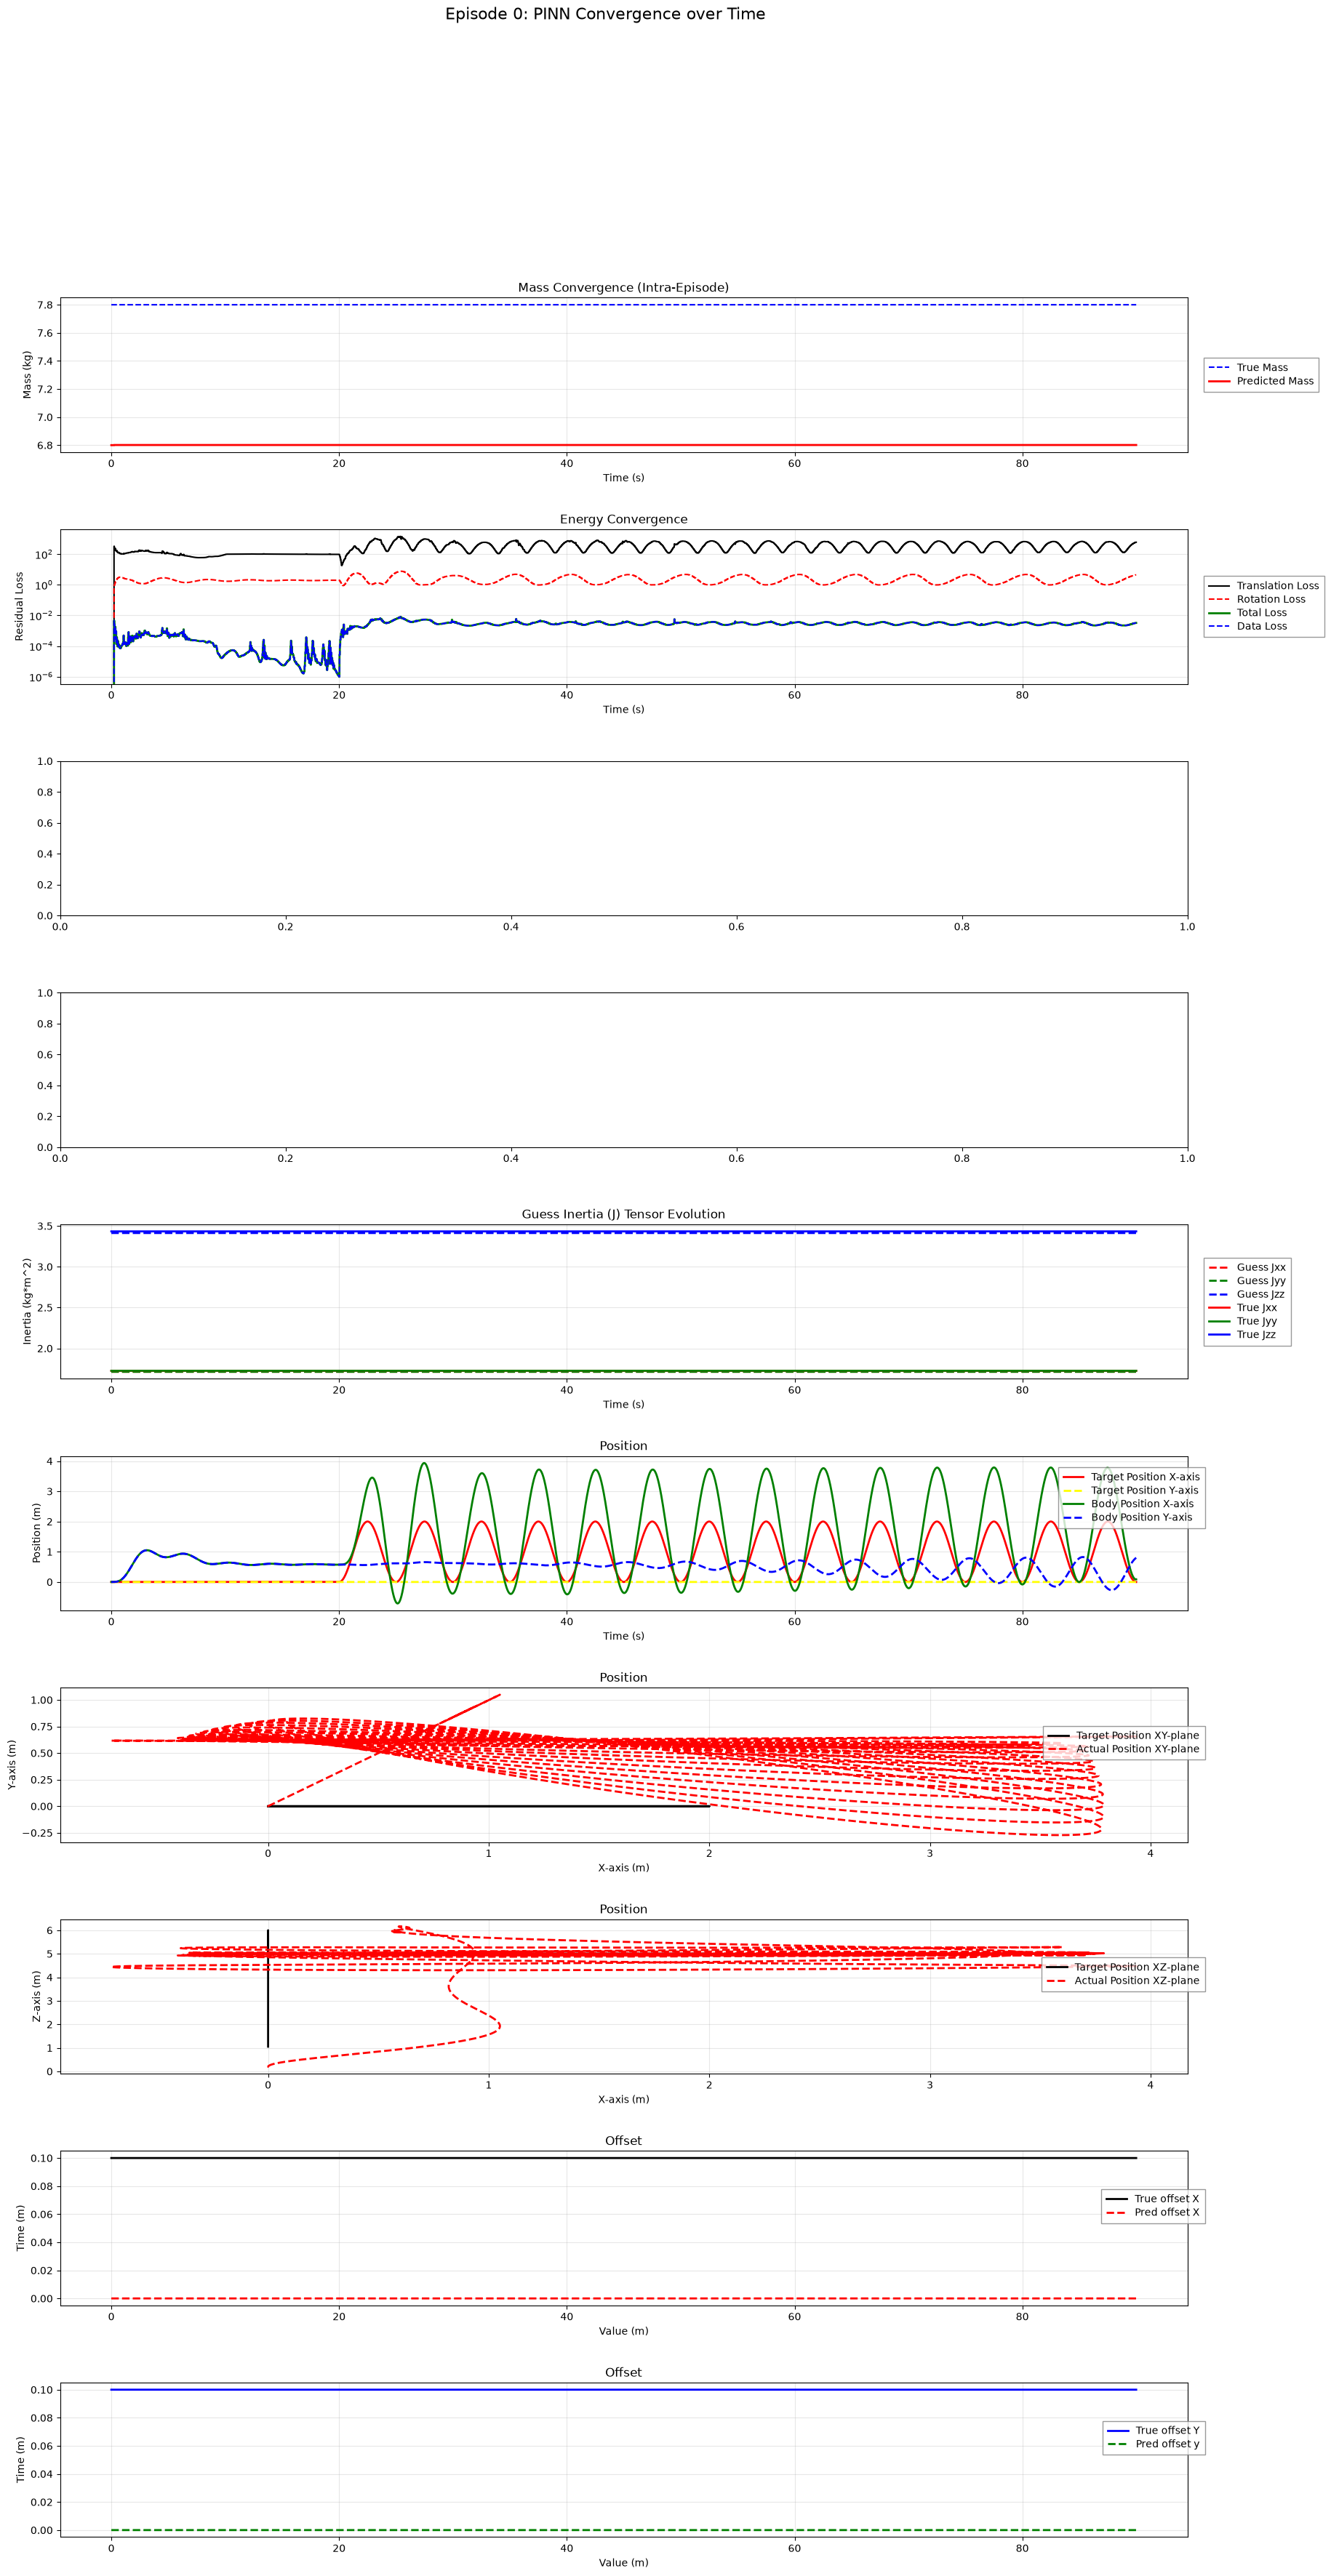

Successfully saved ./flight_data_lawn_ep_0.csv

--- Full Experimental Suite Completed ---


In [8]:
# ==========================================
# INITIALIZE MODEL & HYPERPARAMETERS
# ==========================================
pinn_model = Inverse6DoFPINN().to(device)
optimizer = optim.Adam(pinn_model.parameters(), lr=5e-3)

base_frame_inertia = [1.713, 1.713, 3.413] # True base inertia from PyBullet

WINDOW_SIZE = 50
OPTIMIZE_EVERY_N_STEPS = 8
STEPS_PER_IN_LOOP_OPT = 3
# EPOCHS_PER_EPISODE_END = 100 # Heavy optimization at the end of the flight

curr_episode = 0

now = datetime.now()
filename_timestamp = now.strftime("%Y%m%d_%H%M%S")
txt_log = ""

# ==========================================
# THE EPISODIC LOOP
# ==========================================
while curr_episode < TOTAL_EPISODES:
    # Wipe the notebook output before starting the next episode
    clear_output(wait=True)

    print("*"*36)
    print(f"{curr_episode}-th EPISODE IS STARTING")
    true_offset, true_payload_mass = env.reset()
    print(f"Payload mass: {true_payload_mass}, offset: {true_offset}")
    print(f"True CoG Anomaly at: X={true_offset[0]:.3f}, Y={true_offset[1]:.3f}")

    # calculate base inertia
    base_J, base_mass = get_composite_inertia(p, env.robot_id)
    print(f"Base inertia {base_J} base mass {base_mass}")

    J_frame = np.diag(base_frame_inertia)
    r = np.array(true_offset)   # true payload offset
    J_payload = true_payload_mass * (np.dot(r, r) * np.eye(3) - np.outer(r, r))
    J_system = J_frame + J_payload
    true_j_xx, true_j_yy, true_j_zz = np.diag(J_system)
    print(f"System Total True Jxx {true_j_xx} True Jyy {true_j_yy} True Jzz {true_j_zz}")

    time_now = 0.0
    step_counter = 0

    # 1. SHORT-TERM MEMORY
    buffer_times = collections.deque(maxlen=WINDOW_SIZE)
    buffer_states = collections.deque(maxlen=WINDOW_SIZE)
    buffer_thrusts = collections.deque(maxlen=WINDOW_SIZE)
    buffer_torques = collections.deque(maxlen=WINDOW_SIZE)

    # 2. INTRA-EPISODE HISTORY (For Time-Series Plotting)
    history_time = []
    history_total_loss, history_data_loss, history_trans_loss, history_rot_loss, history_physics_loss = [], [], [], [], []
    history_true_cog_x, history_pred_cog_x = [], []
    history_true_cog_y, history_pred_cog_y = [], []
    history_true_mass, history_pred_mass = [], [] 
    ep_guess_Jxx, ep_guess_Jyy, ep_guess_Jzz = [], [], []
    ep_true_Jxx, ep_true_Jyy, ep_true_Jzz = [], [], []
    ep_true_offset_x, ep_true_offset_y = [], []
    ep_pred_offset_x, ep_pred_offset_y = [], []
    # ep_drone_1_torque, ep_drone_2_torque, ep_drone_3_torque, ep_drone_4_torque = [], [], [], []
    
    # 3D tracking lists for the episode/animation
    ep_actual_x, ep_actual_y, ep_actual_z = [], [], []
    ep_target_x, ep_target_y, ep_target_z = [], [], []
    ep_actual_rpy = []
    ep_compute_times= []

    # Reset parameter guesses 
    guess_mass, guess_x, guess_y = 6.8, 0.0, 0.0
    latest_tot_loss, latest_data_loss, latest_phys_loss, latest_trans_loss, latest_rot_loss = 0.0, 0.0, 0.0, 0.0, 0.0
    guess_j_xx, guess_j_yy, guess_j_zz = 1.515, 1.515, 3.000
    J_xx_computed = float(J_frame[0, 0])
    J_yy_computed = float(J_frame[1, 1])
    J_zz_computed = float(J_frame[2, 2])

    # Reset PINN Network Weights
    with torch.no_grad():
        pinn_model.cog_x.fill_(0.0) 
        pinn_model.cog_y.fill_(0.0)
        pinn_model.mass.fill_(6.8)
        
        pinn_model.J_xx.fill_(1.266)
        pinn_model.J_yy.fill_(1.266)
        pinn_model.J_zz.fill_(2.948)
    optimizer.state.clear() 

    # ==========================================
    # THE CONTINUOUS FLIGHT LOOP
    # ==========================================
    while time_now <= SIMULATION_DURATION:
        
        target_pos, target_vel, target_acc, target_rpy, target_ang_vel = get_trajectory(time_now, path_type=PATH_TRAJECTORY)
        
        # 2. Extract the scalar yaw from the RPY array to prevent the nested array math bug!
        target_yaw_scalar = target_rpy[2]
        
        pos, current_rpy, current_vel, current_ang_vel, current_acc, current_ang_acc, acting_force, follower_thrust_cmds, follower_torque_cmds = env.step(
            FRAME_MASS, max(0.0, guess_mass - FRAME_MASS), TIME_STEP, time_now, 
            target_pos, target_vel, target_ang_vel, target_acc, target_yaw_scalar, [guess_x, guess_y]
        )

        ep_actual_x.append(pos[0])
        ep_actual_y.append(pos[1])
        ep_actual_z.append(pos[2])
        ep_target_x.append(target_pos[0])
        ep_target_y.append(target_pos[1])
        ep_target_z.append(target_pos[2])
        ep_actual_rpy.append(current_rpy)

        # calculate the true Inertia
        # true_j_xx, true_j_yy, true_j_zz = calculate_true_principal_inertia(
        #     base_frame_inertia, true_payload_mass, [true_offset[0], true_offset[1], true_offset[2]])
        
        ep_true_Jxx.append(true_j_xx)
        ep_true_Jyy.append(true_j_yy)
        ep_true_Jzz.append(true_j_zz)

        state_12dof = np.array([
            pos[0], pos[1], pos[2], current_vel[0], current_vel[1], current_vel[2],
            current_rpy[0], current_rpy[1], current_rpy[2], current_ang_vel[0], current_ang_vel[1], current_ang_vel[2]
        ])
        
        buffer_times.append(time_now)
        buffer_states.append(state_12dof)
        buffer_thrusts.append([acting_force[0]]) 
        buffer_torques.append(acting_force[1:4])

        # =========================================================
        # IN-THE-LOOP RECEDING HORIZON OPTIMIZATION
        # =========================================================
        if ENABLE_PINN and len(buffer_times) == WINDOW_SIZE and step_counter % OPTIMIZE_EVERY_N_STEPS == 0:
            t_times = torch.tensor(list(buffer_times), dtype=torch.float32, device=device).unsqueeze(1)
            t_times.requires_grad = True 
            t_states_true = torch.tensor(np.array(list(buffer_states)), dtype=torch.float32, device=device)
            t_thrust = torch.tensor(np.array(list(buffer_thrusts)), dtype=torch.float32, device=device)
            t_torques = torch.tensor(np.array(list(buffer_torques)), dtype=torch.float32, device=device)
            
            # --- START COMPUTATION TIMER ---
            pinn_start_time = time.perf_counter()

            for grad_step in range(STEPS_PER_IN_LOOP_OPT):
                optimizer.zero_grad()
                total_loss, data_loss, trans_loss, rot_loss = train_pinn_step(
                    pinn_model, optimizer, t_times, t_states_true, t_thrust, t_torques,
                    GRAVITY_MSS,
                    LAMBDA_DATA, LAMBDA_TRANS, LAMBDA_ROT
                )

            # --- END COMPUTATION TIMER ---
            pinn_end_time = time.perf_counter()

            # Calculate computation time and equivalent Hz
            compute_time_sec = pinn_end_time - pinn_start_time
            compute_hz = 1.0 / compute_time_sec if compute_time_sec > 0 else 0.0
            
            # Store this in a list initialized at the top of the episode: 
            ep_compute_times.append(compute_time_sec)
                
            with torch.no_grad():
                raw_mass = F.softplus(pinn_model.mass).item() 
                raw_system_cog_x = pinn_model.cog_x.item()
                raw_system_cog_y = pinn_model.cog_y.item()

                raw_j_xx = F.softplus(pinn_model.J_xx).item()
                raw_j_yy = F.softplus(pinn_model.J_yy).item() 
                raw_j_zz = F.softplus(pinn_model.J_zz).item() 
            
            # Singularity clamp and offset calculation
            payload_mass_guess = max(0.05, raw_mass - FRAME_MASS)
            raw_offset_x, raw_offset_y, _ = calculate_payload_offset(FRAME_MASS, payload_mass_guess, [raw_system_cog_x, raw_system_cog_y, 0])

            # EMA low pass filter to remove high frequency spikes
            ALPHA = 1.0 # no filter
            guess_mass = (1.0 - ALPHA) * guess_mass + ALPHA * raw_mass
            guess_x = (1.0 - ALPHA) * guess_x + ALPHA * raw_offset_x
            guess_y = (1.0 - ALPHA) * guess_y + ALPHA * raw_offset_y
            
            guess_j_xx = (1.0 - ALPHA) * guess_j_xx + ALPHA * raw_j_xx
            guess_j_yy = (1.0 - ALPHA) * guess_j_yy + ALPHA * raw_j_yy
            guess_j_zz = (1.0 - ALPHA) * guess_j_zz + ALPHA * raw_j_zz

            guess_payload_mass = max(0.05, guess_mass - FRAME_MASS)
            r_p = np.array([guess_x, guess_y, 0.05])
            r_p_norm_sq = np.dot(r_p, r_p)
            outer_p = np.outer(r_p, r_p)
            J_payload_est = guess_payload_mass * (r_p_norm_sq * np.eye(3) - outer_p)
            J_system_est = J_frame + J_payload_est
            J_xx_computed = float(J_system_est[0, 0])
            J_yy_computed = float(J_system_est[1, 1])
            J_zz_computed = float(J_system_est[2, 2])

            latest_tot_loss = total_loss.item()
            latest_data_loss = data_loss.item()
            latest_rot_loss = rot_loss.item()
            latest_trans_loss = trans_loss.item()

            latest_phys_loss = latest_trans_loss + latest_rot_loss

        # =========================================================
        # RECORD FRAME-BY-FRAME HISTORY FOR PLOTTING
        # =========================================================
        true_tot_mass = FRAME_MASS + true_payload_mass 
        true_system_cog_x = (true_payload_mass * true_offset[0]) / true_tot_mass
        true_system_cog_y = (true_payload_mass * true_offset[1]) / true_tot_mass

        history_time.append(time_now)
        history_true_mass.append(true_tot_mass)
        history_pred_mass.append(guess_mass)
        
        # FIXED: Corrected the System CoG Math!
        current_payload_guess = max(0.0, guess_mass - FRAME_MASS)
        pred_sys_cog_x = (current_payload_guess * guess_x) / guess_mass if guess_mass > 0 else 0
        pred_sys_cog_y = (current_payload_guess * guess_y) / guess_mass if guess_mass > 0 else 0
        
        history_true_cog_x.append(true_system_cog_x)
        history_pred_cog_x.append(pred_sys_cog_x)
        history_true_cog_y.append(true_system_cog_y)
        history_pred_cog_y.append(pred_sys_cog_y)

        # record the offset
        ep_true_offset_x.append(true_offset[0])
        ep_true_offset_y.append(true_offset[1])
        ep_pred_offset_x.append(guess_x)
        ep_pred_offset_y.append(guess_y)

        # calculating total system inertia
        # ep_guess_Jxx.append(guess_j_xx)
        # ep_guess_Jyy.append(guess_j_yy)
        # ep_guess_Jzz.append(guess_j_zz)

        # Use calculated inertia based on
        # estimated mass and offset instead of estimation
        ep_guess_Jxx.append(J_xx_computed)
        ep_guess_Jyy.append(J_yy_computed)
        ep_guess_Jzz.append(J_zz_computed)

        history_total_loss.append(latest_tot_loss)
        history_data_loss.append(latest_data_loss)
        history_physics_loss.append(latest_phys_loss)
        history_trans_loss.append(latest_trans_loss)
        history_rot_loss.append(latest_rot_loss)

        # Crash Detection
        distance_err = np.linalg.norm(np.array(pos) - np.array(target_pos))
        if abs(current_rpy[0]) > 1.5 or abs(current_rpy[1]) > 1.5 or distance_err > 5.0:
            print(f"Flight unstable at t={time_now:.2f}s. Ending rollout early...")
            break 

        time_now += TIME_STEP
        step_counter += 1

    print(f"Episode {curr_episode} Completed | Final Estimates -> Mass: {guess_mass:.3f} kg | Offset: ({guess_x:.3f}, {guess_y:.3f})")

    final_Jxx = np.mean(ep_guess_Jxx[-2000:])   # last ~10s at 240Hz
    final_Jyy = np.mean(ep_guess_Jyy[-2000:])
    final_Jzz = np.mean(ep_guess_Jzz[-2000:])

    true_Jxx = np.mean(ep_true_Jxx[-2000:])
    true_Jyy = np.mean(ep_true_Jyy[-2000:])
    true_Jzz = np.mean(ep_true_Jzz[-2000:])

    print(f"Final Jxx: {final_Jxx:.3f} (true: {true_Jxx:.3f}, error: {100*(final_Jxx-true_Jxx)/true_Jxx:.1f}%)")
    print(f"Final Jyy: {final_Jyy:.3f} (true: {true_Jyy:.3f}, error: {100*(final_Jyy-true_Jyy)/true_Jyy:.1f}%)")
    print(f"Final Jzz: {final_Jzz:.3f} (true: {true_Jzz:.3f}, error: {100*(final_Jzz-true_Jzz)/true_Jzz:.1f}%)")

    # ==========================================
    # RENDER FINAL STATIC PLOT FOR THE EPISODE
    # ==========================================
    if len(history_time) > 0: 
        
        fig = plt.figure(figsize=(20,40))
        # gs = GridSpec(6, 1, figure=fig)
        gs = GridSpec(10, 1, figure=fig, hspace=.5)
        plt.suptitle(f"Episode {curr_episode}: PINN Convergence over Time", fontsize=16)

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[1, 0])
        ax3 = fig.add_subplot(gs[2, 0])
        ax4 = fig.add_subplot(gs[3, 0])
        ax5 = fig.add_subplot(gs[4, 0])
        ax6 = fig.add_subplot(gs[5, 0])
        ax7 = fig.add_subplot(gs[6, 0])
        ax8 = fig.add_subplot(gs[7, 0])
        ax9 = fig.add_subplot(gs[8, 0])
        ax10 = fig.add_subplot(gs[9, 0])

        ax1.plot(history_time, history_true_mass, 'b--', label='True Mass')
        ax1.plot(history_time, history_pred_mass, 'r-', label='Predicted Mass', linewidth=2)
        ax1.set(title='Mass Convergence (Intra-Episode)', xlabel='Time (s)', ylabel='Mass (kg)')
        ax1.grid(True, alpha=0.3)
        # ax1.legend()
        ax1.legend(
            loc='center left',          # Anchors the left side of the legend box
            bbox_to_anchor=(1.01, 0.5), # Pushes it just outside the right edge of the plot
            ncol=1,                     # 1 column looks cleaner when on the side
            frameon=True,             
            edgecolor='gray',         
            fancybox=False,           
            shadow=False,             
            borderpad=0.5,            
            labelspacing=0.3
        )

        # ax2.plot(history_time, history_physics_loss, 'r--', label='Physics Loss')
        ax2.plot(history_time, history_trans_loss, 'black', label='Translation Loss')
        ax2.plot(history_time, history_rot_loss, 'r--', label='Rotation Loss')
        ax2.plot(history_time, history_total_loss, 'g-', label='Total Loss', linewidth=2)
        ax2.plot(history_time, history_data_loss, 'b--', label='Data Loss')
        ax2.set(title='Energy Convergence', xlabel='Time (s)', ylabel='Residual Loss', yscale='log')
        ax2.grid(True, alpha=0.3)
        ax2.legend(
            loc='center left',          # Anchors the left side of the legend box
            bbox_to_anchor=(1.01, 0.5), # Pushes it just outside the right edge of the plot
            ncol=1,                     # 1 column looks cleaner when on the side
            frameon=True,             
            edgecolor='gray',         
            fancybox=False,           
            shadow=False,             
            borderpad=0.5,            
            labelspacing=0.3
        )

        # ax3.plot(history_time, history_true_cog_x, 'b--', label='True Total CoG X')
        # ax3.plot(history_time, history_pred_cog_x, 'r-', label='Predicted Total CoG X', linewidth=2)
        # ax3.set(title='CoG X Estimate', xlabel='Time (s)', ylabel='Position (m)')
        # ax3.grid(True, alpha=0.3)
        # # ax3.legend()
        # ax3.legend(
        #     loc='center left',          # Anchors the left side of the legend box
        #     bbox_to_anchor=(1.01, 0.5), # Pushes it just outside the right edge of the plot
        #     ncol=1,                     # 1 column looks cleaner when on the side
        #     frameon=True,             
        #     edgecolor='gray',         
        #     fancybox=False,           
        #     shadow=False,             
        #     borderpad=0.5,            
        #     labelspacing=0.3
        # )

        # ax4.plot(history_time, history_true_cog_y, 'b--', label='True Total CoG Y')
        # ax4.plot(history_time, history_pred_cog_y, 'r-', label='Predicted Total CoG Y', linewidth=2)
        # ax4.set(title='CoG Y Estimate', xlabel='Time (s)', ylabel='Position (m)')
        # ax4.grid(True, alpha=0.3)
        # # ax4.legend()
        # ax4.legend(
        #     loc='center left',          # Anchors the left side of the legend box
        #     bbox_to_anchor=(1.01, 0.5), # Pushes it just outside the right edge of the plot
        #     ncol=1,                     # 1 column looks cleaner when on the side
        #     frameon=True,             
        #     edgecolor='gray',         
        #     fancybox=False,           
        #     shadow=False,             
        #     borderpad=0.5,            
        #     labelspacing=0.3
        # )

        ax5.plot(history_time, ep_guess_Jxx, color="red",  label='Guess Jxx', linewidth=2, linestyle="--")
        ax5.plot(history_time, ep_guess_Jyy, color="green",  label='Guess Jyy', linewidth=2, linestyle="--")
        ax5.plot(history_time, ep_guess_Jzz, color="blue",  label='Guess Jzz', linewidth=2, linestyle="--")
        ax5.plot(history_time, ep_true_Jxx,  color="red", label='True Jxx', linewidth=2)
        ax5.plot(history_time, ep_true_Jyy,  color="green", label='True Jyy', linewidth=2)
        ax5.plot(history_time, ep_true_Jzz,  color="blue", label='True Jzz', linewidth=2)
        ax5.set(title='Guess Inertia (J) Tensor Evolution', xlabel='Time (s)', ylabel='Inertia (kg*m^2)')
        ax5.grid(True, alpha=0.3)
        # ax5.legend()
        ax5.legend(
            loc='center left',          # Anchors the left side of the legend box
            bbox_to_anchor=(1.01, 0.5), # Pushes it just outside the right edge of the plot
            ncol=1,                     # 1 column looks cleaner when on the side
            frameon=True,             
            edgecolor='gray',         
            fancybox=False,           
            shadow=False,             
            borderpad=0.5,            
            labelspacing=0.3
        )

        ax6.plot(history_time, ep_target_x, color="red",  label='Target Position X-axis', linewidth=2)
        ax6.plot(history_time, ep_target_y, color="yellow",  label='Target Position Y-axis', linewidth=2, linestyle="--")
        ax6.plot(history_time, ep_actual_x, color="green",  label='Body Position X-axis', linewidth=2)
        ax6.plot(history_time, ep_actual_y, color="blue",  label='Body Position Y-axis', linewidth=2, linestyle="--")
        ax6.set(title='Position', xlabel='Time (s)', ylabel='Position (m)')
        ax6.grid(True, alpha=0.3)
        # ax6.legend()
        ax6.legend(
            loc='lower right',          # Anchors the left side of the legend...
            bbox_to_anchor=(1.02, 0.5), # ...just outside the right edge of the plot
            ncol=1,                     
            frameon=True,             
            edgecolor='gray',         
            fancybox=False,           
            shadow=False,             
            borderpad=0.5,            
            labelspacing=0.3          
        )

        ax7.plot(ep_target_x, ep_target_y,  color="black",  label='Target Position XY-plane', linewidth=2)
        ax7.plot(ep_actual_x, ep_actual_y, color="red",  label='Actual Position XY-plane', linewidth=2, linestyle="--")
        ax7.set(title='Position', xlabel='X-axis (m)', ylabel='Y-axis (m)')
        ax7.grid(True, alpha=0.3)
        # ax6.legend()
        ax7.legend(
            loc='lower right',          # Anchors the left side of the legend...
            bbox_to_anchor=(1.02, 0.5), # ...just outside the right edge of the plot
            ncol=1,                     
            frameon=True,             
            edgecolor='gray',         
            fancybox=False,           
            shadow=False,             
            borderpad=0.5,            
            labelspacing=0.3          
        )

        ax8.plot(ep_target_x, ep_target_z,  color="black",  label='Target Position XZ-plane', linewidth=2)
        ax8.plot(ep_actual_x, ep_actual_z, color="red",  label='Actual Position XZ-plane', linewidth=2, linestyle="--")
        ax8.set(title='Position', xlabel='X-axis (m)', ylabel='Z-axis (m)')
        ax8.grid(True, alpha=0.3)
        # ax6.legend()
        ax8.legend(
            loc='lower right',          # Anchors the left side of the legend...
            bbox_to_anchor=(1.02, 0.5), # ...just outside the right edge of the plot
            ncol=1,                     
            frameon=True,             
            edgecolor='gray',         
            fancybox=False,           
            shadow=False,             
            borderpad=0.5,            
            labelspacing=0.3          
        )

        ax9.plot(history_time, ep_true_offset_x,  color="black",  label='True offset X', linewidth=2)
        ax9.plot(history_time, ep_pred_offset_x, color="red",  label='Pred offset X', linewidth=2, linestyle="--")
        ax9.set(title='Offset', xlabel='Value (m)', ylabel='Time (m)')
        ax9.grid(True, alpha=0.3)
        # ax6.legend()
        ax9.legend(
            loc='lower right',          # Anchors the left side of the legend...
            bbox_to_anchor=(1.02, 0.5), # ...just outside the right edge of the plot
            ncol=1,                     
            frameon=True,             
            edgecolor='gray',         
            fancybox=False,           
            shadow=False,             
            borderpad=0.5,            
            labelspacing=0.3          
        )

        ax10.plot(history_time, ep_true_offset_y,  color="blue",  label='True offset Y', linewidth=2)
        ax10.plot(history_time, ep_pred_offset_y, color="green",  label='Pred offset y', linewidth=2, linestyle="--")
        ax10.set(title='Offset', xlabel='Value (m)', ylabel='Time (m)')
        ax10.grid(True, alpha=0.3)
        # ax6.legend()
        ax10.legend(
            loc='lower right',          # Anchors the left side of the legend...
            bbox_to_anchor=(1.02, 0.5), # ...just outside the right edge of the plot
            ncol=1,                     
            frameon=True,             
            edgecolor='gray',         
            fancybox=False,           
            shadow=False,             
            borderpad=0.5,            
            labelspacing=0.3          
        )


        fig.savefig(f"./flight_data_{PATH_TRAJECTORY}_ep_{curr_episode}.png")
        # plt.tight_layout()
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()

        # ==========================================
        # CALCULATE TRAJECTORY RMSE
        # ==========================================
        arr_target = np.array([ep_target_x, ep_target_y, ep_target_z])
        arr_actual = np.array([ep_actual_x, ep_actual_y, ep_actual_z])
        squared_errors = (arr_target - arr_actual) ** 2
        sum_squared_errors = np.sum(squared_errors, axis=0)
        rmse_trajectory = np.sqrt(np.mean(sum_squared_errors))
        
        # Individual Axis RMSE (mean across time, which is axis 1)
        rmse_per_axis = np.sqrt(np.mean(squared_errors, axis=1))
        rmse_x = rmse_per_axis[0]
        rmse_y = rmse_per_axis[1]
        rmse_z = rmse_per_axis[2]


        # ==========================================
        # EXPORT EPISODES to CSV
        # ==========================================
        episode_data = {
            "time_sec": history_time,
            "true_mass_kg": history_true_mass,
            "pred_mass_kg": history_pred_mass,
            "true_cog_x_m": history_true_cog_x,
            "pred_cog_x_m": history_pred_cog_x,
            "true_cog_y_m": history_true_cog_y,
            "pred_cog_y_m": history_pred_cog_y,
            "true_offset_x_m": ep_true_offset_x,
            "true_offset_y_m": ep_true_offset_y,
            "pred_offset_x_m": ep_pred_offset_x,
            "pred_offset_y_m": ep_pred_offset_y,
            "target_x_m": ep_target_x,
            "target_y_m": ep_target_y,
            "target_z_m": ep_target_z,
            "actual_x_m": ep_actual_x,
            "actual_y_m": ep_actual_y,
            "actual_z_m": ep_actual_z,
            "physics_loss": history_physics_loss,
            "data_loss": history_data_loss,
            "total_loss": history_total_loss,
            "trans_loss": history_trans_loss,
            "rot_loss": history_rot_loss,
        }

        # Convert the dictionary into a Pandas DataFrame
        df = pd.DataFrame(episode_data)

        # Save to CSV (index=False prevents pandas from adding an extra column of row numbers)
        csv_filename = f"./flight_data_{PATH_TRAJECTORY}_ep_{curr_episode}.csv"
        
        # downsampling the data
        df.iloc[::10, :].to_csv(csv_filename, index=False)
        
        print(f"Successfully saved {csv_filename}")

    # ==========================================
    # RENDER ANIMATION 
    # ==========================================
    # if (curr_episode  == TOTAL_EPISODES / 2) or curr_episode == TOTAL_EPISODES - 1:
    #     # FIXED: Removed 'plt' and 'curr_episode' arguments from this call to prevent TypeError
    #     video_html = animate_episode_flight(
    #         plt, curr_episode,
    #         ep_actual_x, ep_actual_y, ep_actual_z, ep_actual_rpy, 
    #         ep_target_x, ep_target_y, ep_target_z, 
    #         pred_system_cog_x=pred_sys_cog_x, 
    #         pred_system_cog_y=pred_sys_cog_y, 
    #         frame_skip=8 
    #     )
    #     display(video_html)

    # Calculate average computation metrics for the episode
    avg_compute_time = np.mean(ep_compute_times) * 1000  # Convert to milliseconds
    avg_hz = 1.0 / np.mean(ep_compute_times)

    # Steady-state window: last 20 seconds
    N_SS = int(20 * RATE_HZ)   # 20s at 240 Hz = 4800 samples

    ss_guess_mass = np.mean(history_pred_mass[-N_SS:])
    ss_true_mass  = np.mean(history_true_mass[-N_SS:])

    ss_guess_x = np.mean(ep_pred_offset_x[-N_SS:])
    ss_guess_y = np.mean(ep_pred_offset_y[-N_SS:])
    ss_true_x = np.mean(ep_true_offset_x[-N_SS:])
    ss_true_y = np.mean(ep_true_offset_y[-N_SS:])

    ss_guess_Jxx = np.mean(ep_guess_Jxx[-N_SS:])
    ss_guess_Jyy = np.mean(ep_guess_Jyy[-N_SS:])
    ss_guess_Jzz = np.mean(ep_guess_Jzz[-N_SS:])
    ss_true_Jxx  = np.mean(ep_true_Jxx[-N_SS:])
    ss_true_Jyy  = np.mean(ep_true_Jyy[-N_SS:])
    ss_true_Jzz  = np.mean(ep_true_Jzz[-N_SS:])

    # Percentage errors
    mass_err_pct = 100 * (ss_guess_mass - ss_true_mass) / ss_true_mass
    cogx_err_pct = 100 * (ss_guess_x - ss_true_x) / ss_true_x
    cogy_err_pct = 100 * (ss_guess_y - ss_true_y) / ss_true_y
    jxx_err_pct  = 100 * (ss_guess_Jxx - ss_true_Jxx) / ss_true_Jxx
    jyy_err_pct  = 100 * (ss_guess_Jyy - ss_true_Jyy) / ss_true_Jyy
    jzz_err_pct  = 100 * (ss_guess_Jzz - ss_true_Jzz) / ss_true_Jzz

    # Absolute errors (often more useful than %)
    mass_abs_err = abs(ss_guess_mass - ss_true_mass)
    cogx_abs_err = abs(ss_guess_x - ss_true_x)
    cogy_abs_err = abs(ss_guess_y - ss_true_y)

    # ==========================================
    # Logging Text 
    # ==========================================
    txt_log += "# ========================================== \n"
    txt_log += f"# Simulation Results\n"
    txt_log += "# ========================================== \n"
    txt_log += f"RMSE Total Loss: {latest_tot_loss} \n"
    txt_log += f"RMSE Data Loss: {latest_data_loss} \n"
    txt_log += f"RMSE Physics Loss: {latest_phys_loss} \n"
    txt_log += f"Offset True: x:{true_offset[0]} y:{true_offset[1]} \n"
    txt_log += f"Offset Guess: x:{guess_x} y:{guess_y} \n"
    txt_log += f"Inertia True (initial): Jxx:{base_frame_inertia[0]} Jyy:{base_frame_inertia[1]} Jzz:{base_frame_inertia[2]}\n"
    txt_log += f"Inertia Guess with payload: x:{guess_j_xx} y:{guess_j_yy} \n"
    txt_log += f"Trajectory Loss RMSE: {rmse_trajectory:.4f} meters \n"
    txt_log += f"Trajectory x-axis loss: {rmse_x:.4f} meters \n"
    txt_log += f"Trajectory y-axis loss: {rmse_y:.4f} meters \n"
    txt_log += f"Trajectory z-axis loss: {rmse_z:.4f} meters \n"
    txt_log += f"Avg PINN Compute Time: {avg_compute_time:.2f} ms ({avg_hz:.1f} Hz) \n"

    txt_log += f"\n=== STEADY-STATE SUMMARY === \n"
    txt_log += f"Mass: {ss_guess_mass:.3f} vs {ss_true_mass:.3f}  (err {mass_err_pct:+.2f}%, {mass_abs_err:.3f} kg)\n"
    txt_log += f"Offset-x: {ss_guess_x:.4f} vs {ss_true_x:.4f}  (err {cogx_err_pct:+.1f}%, {cogx_abs_err*1000:.1f} mm)\n"
    txt_log += f"Offset-y: {ss_guess_y:.4f} vs {ss_true_y:.4f}  (err {cogy_err_pct:+.1f}%, {cogy_abs_err*1000:.1f} mm)\n"
    txt_log += f"Jxx:  {ss_guess_Jxx:.4f} vs {ss_true_Jxx:.4f}  (err {jxx_err_pct:+.2f}%)\n"
    txt_log += f"Jyy:  {ss_guess_Jyy:.4f} vs {ss_true_Jyy:.4f}  (err {jyy_err_pct:+.2f}%)\n"
    txt_log += f"Jzz:  {ss_guess_Jzz:.4f} vs {ss_true_Jzz:.4f}  (err {jzz_err_pct:+.2f}%)\n"
    txt_log += f"Traj RMSE: {rmse_trajectory:.4f} m\n"
    txt_log += f"Avg PINN compute: {np.mean(ep_compute_times)*1000:.2f} ms ({1/np.mean(ep_compute_times):.1f} Hz)\n"

    curr_episode += 1

# Define the path (saving it alongside your PyTorch weights)
log_file_path = f"flight_data_{PATH_TRAJECTORY}.txt"

# rewrite existing file
with open(log_file_path, "w") as file:
    file.write(txt_log + "\n") # Added an extra newline for clean spacing

print("\n--- Full Experimental Suite Completed ---")

# Save the video
p.stopStateLogging(log_id)
p.disconnect()


# ==========================================
# SAVE THE PYTORCH MODEL WEIGHTS
# ==========================================
# MODEL_DIR = "calibration_results"
# os.makedirs(MODEL_DIR, exist_ok=True)
# model_save_path = os.path.join(MODEL_DIR, "inverse_pinn_6dof_final.pth")

# torch.save(pinn_model.state_dict(), model_save_path)
# print(f"Model state dictionary saved to: {model_save_path}")

## Data Analyze

In [9]:
import pandas as pd
import numpy as np

log_data = pd.read_csv('flight_data_figure_eight_3d_ep_0.csv')
SCALE_DATA  = np.median(log_data['data_loss'][-100:])
SCALE_TRANS = np.median(log_data['trans_loss'][-100:])
SCALE_ROT   = np.median(log_data['rot_loss'][-100:])

print(f"DATA loss {SCALE_DATA} TRANS loss {SCALE_TRANS} ROT loss {SCALE_ROT}")

FileNotFoundError: [Errno 2] No such file or directory: 'flight_data_figure_eight_3d_ep_0.csv'

In [ ]:
import pandas as pd
import numpy as np

def calculate_csv_rmse(file_path):
    """
    Reads a flight log CSV and calculates the payload offset RMSE.
    """
    # 1. Load the CSV data into a Pandas DataFrame
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: Could not find {file_path}")
        return

    # 2. Extract the relevant columns
    # Update these string names if your actual CSV headers are different
    try:
        true_x = df['true_offset_x_m']
        pred_x = df['pred_offset_x_m']
        true_y = df['true_offset_y_m']
        pred_y = df['pred_offset_y_m']
    except KeyError as e:
        print(f"Error: Missing column in CSV - {e}")
        return

    # 3. Calculate dimensional errors
    error_x = true_x - pred_x
    error_y = true_y - pred_y

    # 4. Calculate RMSE for each axis
    rmse_x = np.sqrt(np.mean(error_x ** 2))
    rmse_y = np.sqrt(np.mean(error_y ** 2))

    # 5. Calculate the total combined Euclidean distance RMSE
    euclidean_errors = np.sqrt(error_x ** 2 + error_y ** 2)
    rmse_total = np.sqrt(np.mean(euclidean_errors ** 2))

    # 6. Print the formatted results
    print("=" * 45)
    print(f"       RMSE RESULTS: {file_path}       ")
    print("=" * 45)
    print(f"X-Axis Offset RMSE:         {rmse_x:.4f} meters")
    print(f"Y-Axis Offset RMSE:         {rmse_y:.4f} meters")
    print(f"Total Combined Offset RMSE: {rmse_total:.4f} meters")
    print("=" * 45)

In [ ]:
calculate_csv_rmse("paper_eight_naikturun_buat_conference/flight_data_figure_eight_3d_ep_1.csv")

       RMSE RESULTS: paper_eight_naikturun_buat_conference/flight_data_figure_eight_3d_ep_1.csv       
X-Axis Offset RMSE:         0.1564 meters
Y-Axis Offset RMSE:         0.0901 meters
Total Combined Offset RMSE: 0.1805 meters
